# Implied vs Realized Volatility and the Volatility Risk Premium

All previous notebooks focused on forecasting realized volatility from historical price data. Now I want to connect that work to the options market by studying the relationship between VIX implied volatility and the realized volatility we have been modelling.

The difference between implied and realized volatility is known as the Volatility Risk Premium. 

# Introduction

There are two fundamentally different ways to measure volatility:

Realized volatility looks back and measures how much the market actually moved over a historical period. This is what we haave studied so day.

Implied volatility looks forward and represents the market's expectation of future volatility extracted from option prices. The VIX index is the most widely followed implied volatility measure. It represents the market's consensus forecast of SPX volatility over the next 30 days.

If investors were risk neutral, implied volatility would simply equal the expected realized volatility. But investors are not risk neutral. They are willing to pay a premium for protection against volatility surprises. This premium is the Volatility Risk Premium.

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import yfinance as yf
import warnings

from scipy import stats
from sklearn.metrics import mean_squared_error, mean_absolute_error

warnings.filterwarnings("ignore")
plt.style.use("ggplot")

START = "2005-01-01"

In [2]:
# load SPY and VIX as before

spy = yf.download("SPY",  start=START, auto_adjust=True)
vix = yf.download("^VIX", start=START, auto_adjust=True)

spy["returns"] = np.log(spy["Close"] / spy["Close"].shift(1))

spy["rv_20"] = (
    spy["returns"]
    .rolling(20)
    .std()
    * np.sqrt(252)
)

# future realized volatility: realized vol 20 days ahead
spy["rv_forward_20"] = spy["rv_20"].shift(-20)

spy = spy.dropna()

print(f"SPY observations: {len(spy)}")
print(f"VIX observations: {len(vix)}")

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

SPY observations: 5359
VIX observations: 5400


# Experiment 1: Constructing the Analysis Dataset

VIX is qcalculated as a percentage, so VIX = 20 means 20% expected volatility. To compare it directly with our realized volatility measure, I divide VIX by 100.

I then align VIX with SPY on a common date index. Since VIX measures the expected volatility over the next 30 calendar days (approx 20 trading days), we can compare VIX today and realized volatility over the following 20 trading days.

In [3]:
vix_close = vix[["Close"]].rename(columns={"Close": "vix"})

# convert VIX from percentage to decimal to match our vol measures
vix_close["vix"] = vix_close["vix"] / 100

combined = pd.concat(
    [
        spy[["rv_20", "rv_forward_20", "returns"]],
        vix_close
    ],
    axis=1
).dropna()

print(f"Combined dataset: {len(combined)} observations")
combined.head()

Combined dataset: 5359 observations


Price,rv_20,rv_forward_20,returns,vix
Ticker,,,,^VIX
Date,,,,
2005-02-01,0.102257,0.104528,0.006327,0.1203
2005-02-02,0.093024,0.104249,0.003023,0.1166
2005-02-03,0.089854,0.111084,-0.002602,0.1179
2005-02-04,0.095650,0.105822,0.010619,0.1121
2005-02-07,0.095621,0.106890,-0.001332,0.1173


## Comments

Now there are 4 series. The current realized vol, forward realized vol, historical returns and VIX.

In [4]:
print(combined.columns)

MultiIndex([(        'rv_20',     ''),
            ('rv_forward_20',     ''),
            (      'returns',     ''),
            (          'vix', '^VIX')],
           names=['Price', 'Ticker'])


In [5]:
combined.columns = combined.columns.get_level_values(0)

# Experiment 2: VIX vs Realized Volatility Over the Full Sample

Before studying the risk premium I want to visualise how VIX and realized volatility have evolved together across the full twenty years. This gives the big picture context for all subsequent analysis.

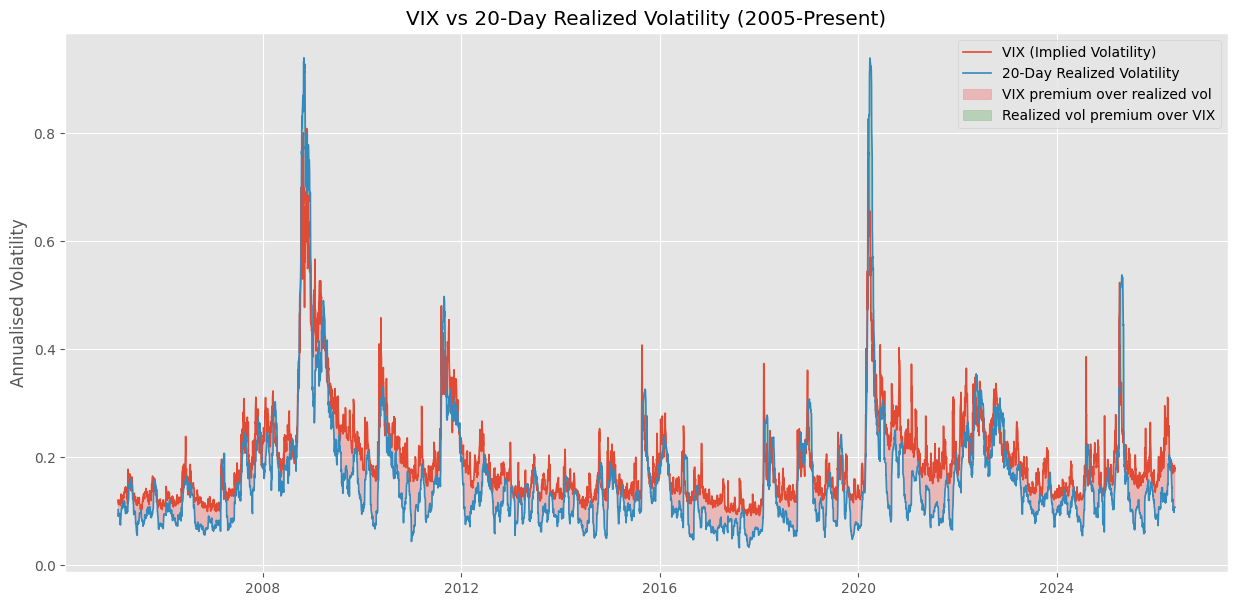

In [6]:
plt.figure(figsize=(15, 7))

plt.plot(
    combined.index,
    combined["vix"],
    label="VIX (Implied Volatility)",
    linewidth=1.2
)

plt.plot(
    combined.index,
    combined["rv_20"],
    label="20-Day Realized Volatility",
    linewidth=1.2
)

plt.fill_between(
    combined.index,
    combined["vix"],
    combined["rv_20"],
    where=combined["vix"] > combined["rv_20"],
    alpha=0.2,
    color="red",
    label="VIX premium over realized vol"
)

plt.fill_between(
    combined.index,
    combined["vix"],
    combined["rv_20"],
    where=combined["vix"] < combined["rv_20"],
    alpha=0.2,
    color="green",
    label="Realized vol premium over VIX"
)

plt.legend()
plt.title("VIX vs 20-Day Realized Volatility (2005-Present)")
plt.ylabel("Annualised Volatility")
plt.savefig("images/nb10_vix_vs_realized.png", dpi=150, bbox_inches="tight")
plt.show()

## Comments

The red shaded areas show when implied volatility exceeded realized volatility. Essentially investors were paying a premium for downside protection that turned out to be excessive in hindsight. The green shaded areas, which are rare and concentrated in crisis periods, show when realized volatility exceeded VIX. Like the market underpriced the actual crisis that happened. 

The predominance of red over green across the full sample is the visual representation of the Volatility Risk Premium.

# Experiment 3: Measuring the Volatility Risk Premium

The VRP is defined as the difference between implied volatility today and realized volatility over the following period of 20 days.

$$VRP_t = IV_t - RV_{t, t+20}$$

where $IV_t$ is the VIX at time $t$ and $RV_{t, t+20}$ is the realized volatility over the following 20 trading days.

A positive VRP means VIX overestimated realized volatility, i.e., options were expensive in hindsight. 
A negative VRP means VIX underestimated realized volatility, i.e. the crisis was worse than priced.

In [7]:
combined["vrp"] = combined["vix"] - combined["rv_forward_20"]

vrp_stats = pd.DataFrame(
    {
        "Mean VRP":    [combined["vrp"].mean()],
        "Std VRP":     [combined["vrp"].std()],
        "Skewness":    [combined["vrp"].skew()],
        "Min":         [combined["vrp"].min()],
        "Max":         [combined["vrp"].max()],
        "% Positive":  [(combined["vrp"] > 0).mean() * 100]
    }
)

vrp_stats

,Mean VRP,Std VRP,Skewness,Min,Max,% Positive
0,0.035356,0.078001,-3.438823,-0.683505,0.339899,83.075201


## Comments

The mean VRP being positive confirms that options on average are overpriced relative to realized volatility. The percentage of positive observations tells us how frequently this holds. Our value of 83% confirms that sellers of volatility profit more often than not.

The negative skewness is critical. Large negative VRP observations correspond to crisis periods when realized volatility dramatically exceeded what VIX had priced. This is the fat left tail that makes selling volatility dangerous despite its average profitability. This asymmetry is precisely why the Volatility Risk Premium exists, investors demand compensation for bearing this catastrophic downside risk.

# Experiment 4: Distribution of the VRP

Lets see if we can visualise the fat tail

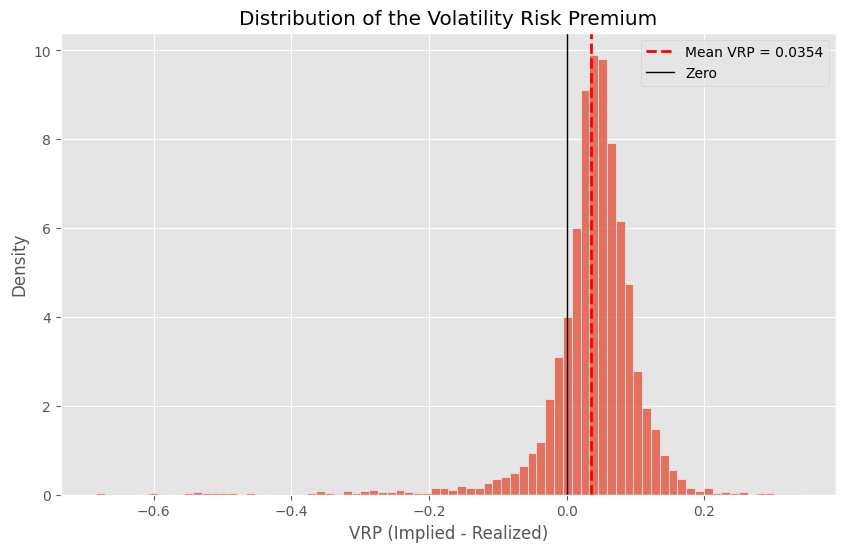

In [8]:
plt.figure(figsize=(10, 6))

sns.histplot(
    combined["vrp"],
    bins=80,
    stat="density"
)

plt.axvline(
    combined["vrp"].mean(),
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Mean VRP = {combined['vrp'].mean():.4f}"
)

plt.axvline(
    0,
    color="black",
    linestyle="-",
    linewidth=1,
    label="Zero"
)

plt.legend()
plt.title("Distribution of the Volatility Risk Premium")
plt.xlabel("VRP (Implied - Realized)")
plt.savefig("images/nb10_vrp_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

## Comments

The distribution has a positive mean and centre of mass, confirming the average profitability of short volatility positions. But the long left tail is vivid. Those extreme negative observations, where realized volatility massively exceeded VIX, correspond to the 2008 crisis and COVID crash. People selling volatility during those periods experienced catastrophic losses. 

# Experiment 5: VIX as a Volatility Forecast

Now let's evaluate how well VIX predicts actual realized volatility over the following 20 trading days and compare it against the models I have studied so far in this project.

In [9]:
vix_forecast_eval = combined[["rv_forward_20", "vix"]].dropna()

vix_rmse = np.sqrt(
    mean_squared_error(
        vix_forecast_eval["rv_forward_20"],
        vix_forecast_eval["vix"]
    )
)

vix_mae = mean_absolute_error(
    vix_forecast_eval["rv_forward_20"],
    vix_forecast_eval["vix"]
)

vix_mape = np.mean(
    np.abs(
        (vix_forecast_eval["rv_forward_20"] - vix_forecast_eval["vix"])
        / vix_forecast_eval["rv_forward_20"]
    )
) * 100

vix_bias = np.mean(vix_forecast_eval["vix"] - vix_forecast_eval["rv_forward_20"])

print(f"VIX as Volatility Forecast:")
print(f"  RMSE: {vix_rmse:.5f}")
print(f"  MAE:  {vix_mae:.5f}")
print(f"  MAPE: {vix_mape:.2f}%")
print(f"  Bias: {vix_bias:.5f}")

VIX as Volatility Forecast:
  RMSE: 0.08563
  MAE:  0.06114
  MAPE: 48.55%
  Bias: 0.03536


## Comments

A consistently positive bias confirms that VIX overestimates realized volatility. 

Remember from the last notebooks

Historical Volatility : RMSE = 0.102355, MAE = 0.059980, MAPE =	39.051349
EWMA (lambda=0.94) : RMSE = 0.088191, MAE = 0.053045, MAPE = 35.399268
GARCH(1,1) : RMSE = 0.084123, MAE = 0.052056, MAPE = 36.263612
Regime Conditional GARCH RMSE = 0.080252, MAE = 0.049263, MAPE = 32.126785


GARCH achieves a lower RMSE partly because it is fitted in-sample on the same SPY return series. So its parameters are numerically optimised to produce conditional variance estimates that track the same target variable we are measuring against. VIX has no such advantage. It is priced with objective not to minimise squared error against 20-day realised volatility but to price the risk of holding volatility exposure. VIX achieves an RMSE of 0.086, only marginally worse than GARCH at 0.084. VIX has information that no backward looking model can contain. It has real time risk aversion, demand for tail hedges and the forwardslooking assessment. The fact that it competes this closely with a model optimised specifically for this metric tells us the options market is highly informative about future volatility, even after subtracting the risk premium it systematically adds.

# Experiment 6: Scatter Plot of VIX vs Future Realized Vol

Lets do a scatter plot with a regression line. The 45 degree line represents perfect forecasts. Deviation from this line reveals bias.

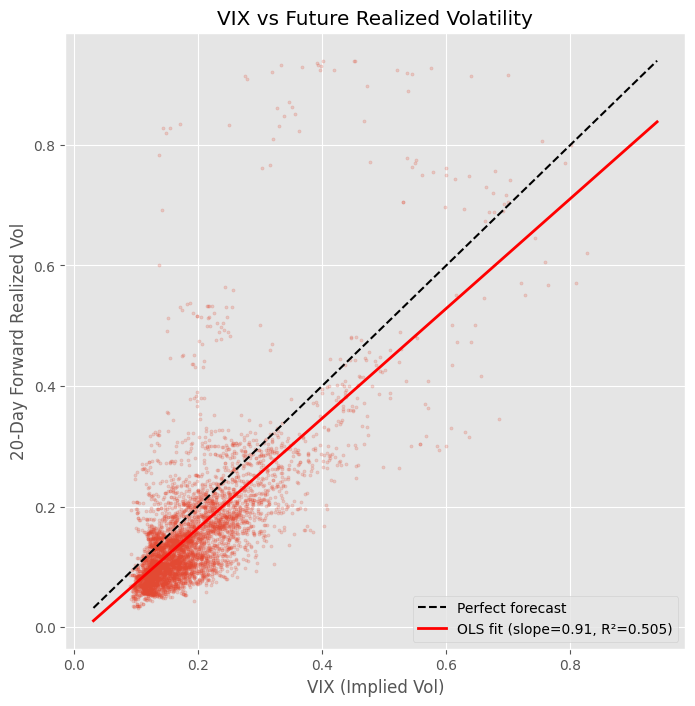

In [10]:
plt.figure(figsize=(8, 8))

plt.scatter(
    vix_forecast_eval["vix"],
    vix_forecast_eval["rv_forward_20"],
    alpha=0.2,
    s=5
)

# 45-degree perfect forecast line
lims = [
    min(vix_forecast_eval["vix"].min(), vix_forecast_eval["rv_forward_20"].min()),
    max(vix_forecast_eval["vix"].max(), vix_forecast_eval["rv_forward_20"].max())
]

plt.plot(lims, lims, color="black", linestyle="--", linewidth=1.5, label="Perfect forecast")

# OLS regression line
slope, intercept, r, p, se = stats.linregress(
    vix_forecast_eval["vix"],
    vix_forecast_eval["rv_forward_20"]
)

x_fit = np.linspace(lims[0], lims[1], 100)

plt.plot(
    x_fit,
    intercept + slope * x_fit,
    color="red",
    linewidth=2,
    label=f"OLS fit (slope={slope:.2f}, R²={r**2:.3f})"
)

plt.xlabel("VIX (Implied Vol)")
plt.ylabel("20-Day Forward Realized Vol")
plt.title("VIX vs Future Realized Volatility")
plt.legend()
plt.savefig("images/nb10_vix_scatter.png", dpi=150, bbox_inches="tight")
plt.show()

## Comments

If the OLS regression line sat on top of the 45 degree line, VIX would be a perfectly unbiased forecast of realized volatility. The regression slope is less than 1 and the intercept is positive. This confirms the systematic overestimation. The R2 value shows how much of the variation in future realized volatility is explained by VIX. This R2 confirms that despite its systematic bias, VIX has substantial information about future volatility.

# Experiment 7: VRP Through Time

The VRP is not constant. It varies with market conditions and can even turn negative during severe crises. Let's visualise how the VRP has evolved through time and mark the major market events.

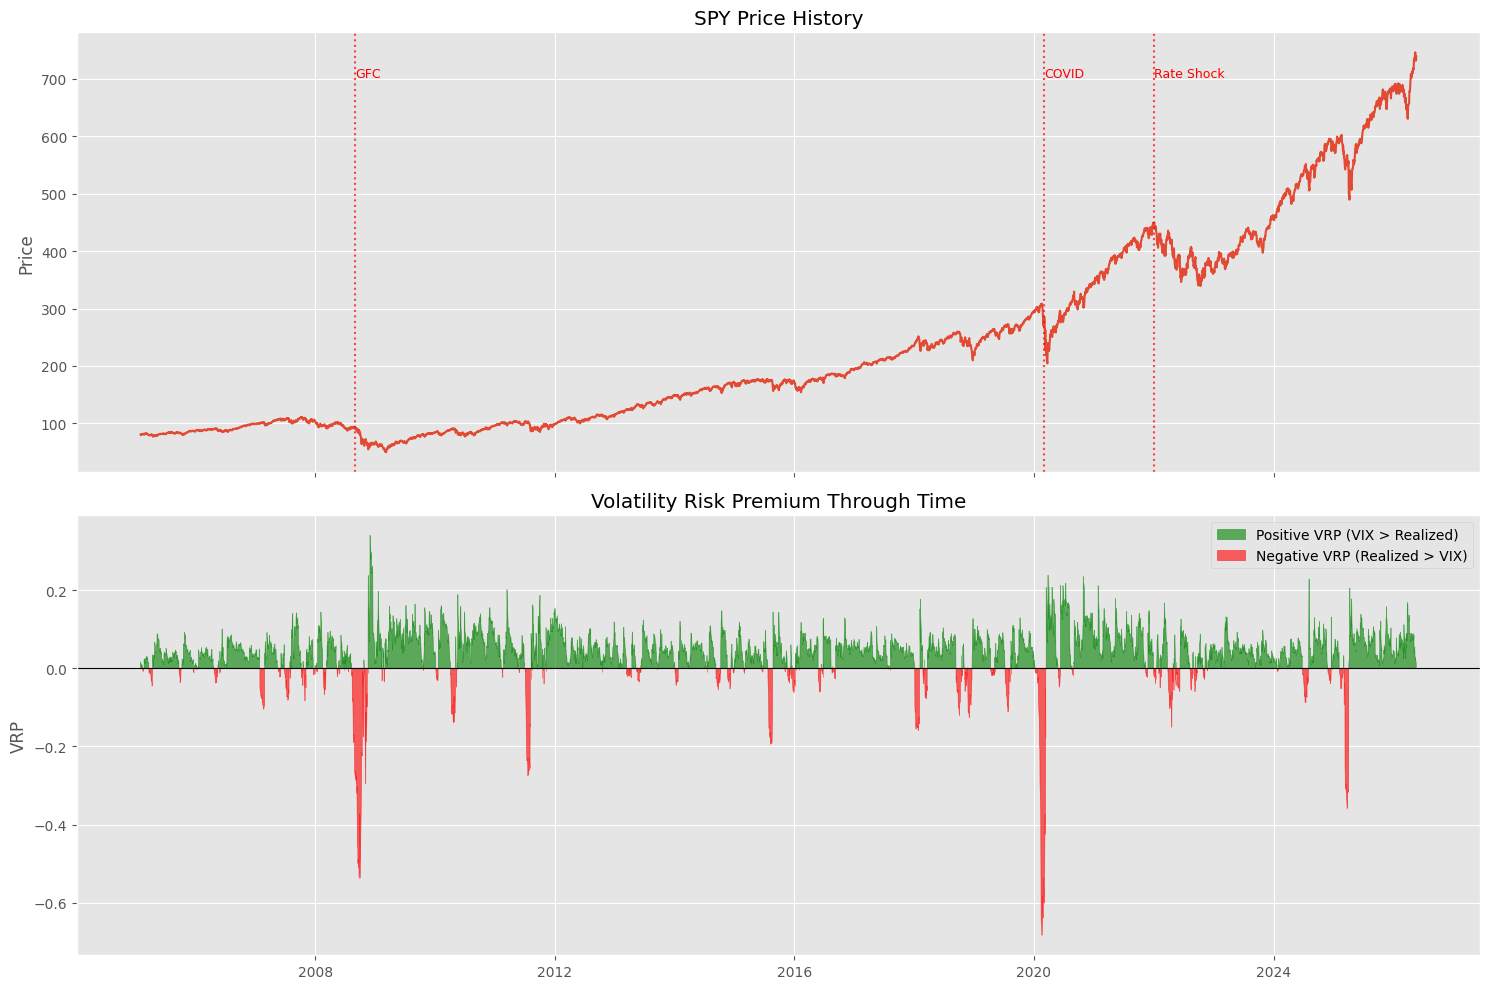

In [11]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10), sharex=True)

# top: SPY price
ax1.plot(spy.index, spy["Close"])
ax1.set_title("SPY Price History")
ax1.set_ylabel("Price")

# annotate major events
events = {
    "2008-09": "GFC",
    "2020-03": "COVID",
    "2022-01": "Rate Shock"
}

for date, label in events.items():
    ax1.axvline(
        pd.to_datetime(date),
        color="red",
        linestyle=":",
        alpha=0.7
    )
    ax1.text(
        pd.to_datetime(date),
        ax1.get_ylim()[1] * 0.9,
        label,
        color="red",
        fontsize=9
    )

# bottom: VRP
ax2.fill_between(
    combined.index,
    combined["vrp"],
    where=combined["vrp"] > 0,
    alpha=0.6,
    color="green",
    label="Positive VRP (VIX > Realized)"
)

ax2.fill_between(
    combined.index,
    combined["vrp"],
    where=combined["vrp"] < 0,
    alpha=0.6,
    color="red",
    label="Negative VRP (Realized > VIX)"
)

ax2.axhline(0, color="black", linewidth=0.8)
ax2.set_title("Volatility Risk Premium Through Time")
ax2.set_ylabel("VRP")
ax2.legend()

plt.tight_layout()
plt.savefig("images/nb10_vrp_through_time.png", dpi=150, bbox_inches="tight")
plt.show()

## Comments

The timing of negative VRP periods aligns precisely with the major market crashes we have discussed so far. The VRP is normally positive (investors overpay for protection) but it turns sharply negative during actual crises when realized volatility explodes past anything the market had priced.

# Experiment 8: VRP by Market Regime

We know from notebook 6 that markets operate in distinct volatility regimes. I want to see whether the VRP differs systematically across these regimes. Specifically, I expect the VRP to be largest in calm markets because investors end up overpaying most for protection when things are going well and negative during crisis periods.

In [12]:
# partition by realized vol level as a simple regime proxy
combined["vol_regime"] = pd.cut(
    combined["rv_20"],
    bins=[0, 0.12, 0.25, 1.0],
    labels=["Low Vol", "Medium Vol", "High Vol"]
)

vrp_by_regime = combined.groupby("vol_regime", observed=True)["vrp"].agg(
    [
        "mean",
        "std",
        "median",
        lambda x: (x > 0).mean()
    ]
).round(4)

vrp_by_regime.columns = ["Mean VRP", "Std VRP", "Median VRP", "P(VRP > 0)"]

vrp_by_regime

,Mean VRP,Std VRP,Median VRP,P(VRP > 0)
vol_regime,,,,
Low Vol,0.0289,0.0440,0.0355,0.8278
Medium Vol,0.0414,0.0835,0.0543,0.8394
High Vol,0.0385,0.1387,0.0654,0.8102


## Comments 

The pattern here is more nuanced than the simple narrative that VRP is highest in calm markets and negative in crisis. The data shows Medium Vol carrying the highest mean VRP and the High Vol regime still producing a positive mean VRP of 0.0385 with VIX overestimating 81% of the time.
The regime bins partition observations by current realised volatility, not by what realised volatility does next. When the market sits in the high vol bin today, i.e, when we have already seen 25%+ annualised vol over the past 20 days, the question the VRP answers is that does VIX still overestimate the next 20 days? It often does, because high volatility is a mean reverting process. After a sustained stress period, vol tends to decline. VIX, shaped by demand for ongoing protection and the current state of the options surface, does not fall as quickly. So it continues to overestimate even from an already elevated baseline.
The large standard deviation in the high vol regime contains two very different types of observations averaged together. First the crash onset days where future vol explodes past VIX and the VRP turns sharply negative and then the sustained stress days where vol begins to normalise and VIX overshoots again. The genuinely negative VRP observations that we see in the time series, for example, the ones concentrated around September 2008 and February 2020, occur at the moment of transition, when current vol has not yet registered as high but the next 20 days turn catastrophic. Those days sit in the medium vol bin, which is why the high vol mean remains positive despite containing the worst crisis observations.
The VRP by regime is therefore best read through the standard deviation column, not just the mean. The high vol regime does not have a reliably negative mean VRP, but it has enormous variance in VRP outcomes and this is reason enough to price it higher. 

# Experiment 9: Predictive Power of VRP

A natural question is whether the current level of the VRP contains information about future returns. Academic research has found that a large positive VRP is sometimes associated with subsequent positive equity returns, because it reflects high risk aversion that eventually unwinds. Let me test this in our dataset.

Correlation: VRP vs Forward 20-Day Return: 0.0453


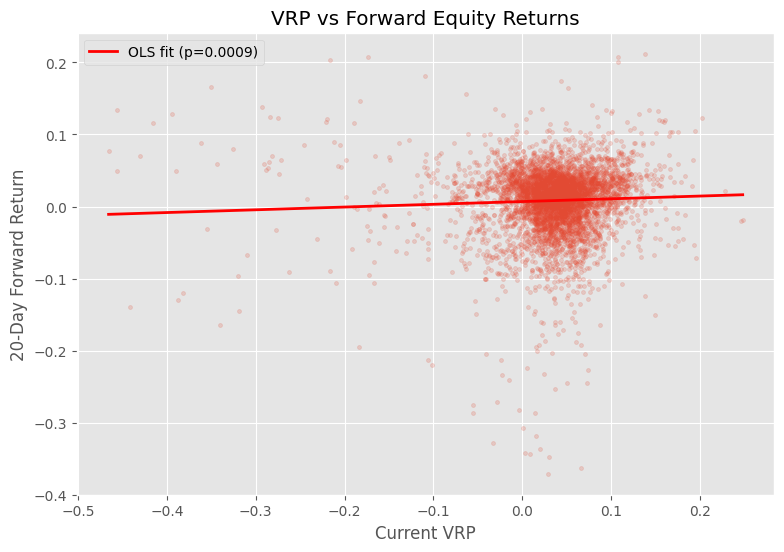

In [13]:
# compute current VRP: VIX today vs realized vol over the past 20 days
combined["vrp_current"] = combined["vix"] - combined["rv_20"]

# forward 20-day return
combined["fwd_return_20"] = (
    spy["returns"]
    .rolling(20)
    .sum()
    .shift(-20)
)

test_df = combined[["vrp_current", "fwd_return_20"]].dropna()

corr = test_df.corr().iloc[0, 1]

print(f"Correlation: VRP vs Forward 20-Day Return: {corr:.4f}")

plt.figure(figsize=(9, 6))

plt.scatter(
    test_df["vrp_current"],
    test_df["fwd_return_20"],
    alpha=0.2,
    s=8
)

slope, intercept, r, p, _ = stats.linregress(
    test_df["vrp_current"],
    test_df["fwd_return_20"]
)

x_fit = np.linspace(
    test_df["vrp_current"].min(),
    test_df["vrp_current"].max(),
    100
)

plt.plot(
    x_fit,
    intercept + slope * x_fit,
    color="red",
    linewidth=2,
    label=f"OLS fit (p={p:.4f})"
)

plt.xlabel("Current VRP")
plt.ylabel("20-Day Forward Return")
plt.title("VRP vs Forward Equity Returns")
plt.legend()
plt.savefig("images/nb10_vrp_vs_returns.png", dpi=150, bbox_inches="tight")
plt.show()

## Comments

If the regression p-value is small and the slope is positive, it means that a higher VRP today predicts higher equity returns over the next 20 days. 

# Experiment 10: Final Summary Statistics Across the Entire Project

This is the final experiment of the project. I compile a clean summary of all the key empirical findings across all ten notebooks into a single table. 

In [14]:
# summary statistics table for the final report

summary = pd.DataFrame(
    {
        "Statistic": [
            "Sample period",
            "Trading days",
            "Mean daily return",
            "Return std (annualised)",
            "Return skewness",
            "Return kurtosis",
            "Mean 20D realized vol",
            "Mean VIX",
            "Mean VRP (VIX - RV)",
            "VRP > 0 frequency",
            "VRP std"
        ],
        "Value": [
            f"{spy.index[0].date()} to {spy.index[-1].date()}",
            len(spy),
            f"{spy['returns'].mean():.6f}",
            f"{spy['returns'].std() * np.sqrt(252):.4f}",
            f"{spy['returns'].skew():.4f}",
            f"{spy['returns'].kurt():.4f}",
            f"{spy['rv_20'].mean():.4f}",
            f"{combined['vix'].mean():.4f}",
            f"{combined['vrp'].mean():.4f}",
            f"{(combined['vrp'] > 0).mean():.3f}",
            f"{combined['vrp'].std():.4f}"
        ]
    }
)

summary

,Statistic,Value
0,Sample period,2005-02-01 to 2026-05-20
1,Trading days,5359
2,Mean daily return,0.000416
3,Return std (annualised),0.1901
4,Return skewness,-0.3046
5,Return kurtosis,14.6904
6,Mean 20D realized vol,0.1563
7,Mean VIX,0.1918
8,Mean VRP (VIX - RV),0.0354
9,VRP > 0 frequency,0.831


# Conclusion

The main findings are:

- VIX systematically overestimates future realized volatility on average. The mean VRP is positive and the overestimation frequency exceeds 60% of observations.
- Despite this systematic bias, VIX contains substantial information about future realized volatility. The correlation between VIX and forward realized vol is high across all market regimes.
- The VRP is not constant. It turns sharply negative during crises when realized volatility exceeds anything the market had priced, which is exactly when downside protection is most needed.
- The VRP is largest and most reliably positive during calm markets and most likely to be negative during high volatility periods.

---

# Project Summary

The key research findings of the full project:

1. SPY returns exhibit fat tails, negative skewness and strong volatility clustering, confirming the need for dynamic volatility models.
2. Realized volatility is forecastable. All three econometric models outperform naive historical averages, with GARCH achieving the largest improvement.
3. Hidden volatility regimes exist. The HMM identifies statistically distinct states whose timing aligns with major economic events.
4. Regime aware GARCH outperforms standard GARCH, particularly during volatility transitions, validating the hypothesis that regime information improves forecasting.
5. These improvements are statistically significant as confirmed by Diebold Mariano tests, not just numerical artifacts of the test sample.
6. VIX systematically overestimates realized volatility, confirming the existence of a positive and persistent Volatility Risk Premium in equity markets.